# 02 Model Training


In [2]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter
from ultralytics import YOLO

print("all imports are successful ")

all imports are successful 


In [3]:
#paths
BASE_DIR  = Path("../")
DATA_DIR  = BASE_DIR / "data/statefarm_subject_split"
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR   = DATA_DIR / "val"

REPORTS_DIR = BASE_DIR / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

#class labels
CLASS_NAMES = {
    "c0": "Safe Driving",
    "c1": "Texting (Right)",
    "c2": "Phone (Right)",
    "c3": "Texting (Left)",
    "c4": "Phone (Left)",
    "c5": "Radio",
    "c6": "Drinking",
    "c7": "Reaching Behind",
    "c8": "Hair/Makeup",
    "c9": "Talking to Passenger"
}

In [4]:
def count_images(split_dir):
    counts = {}
    for folder in sorted(split_dir.iterdir()):
        if folder.is_dir():
            n = len([f for f in folder.iterdir()
                     if f.suffix.lower() in [".jpg", ".jpeg", ".png"]])
            counts[folder.name] = n
    return counts

train_counts = count_images(TRAIN_DIR)
val_counts   = count_images(VAL_DIR)

# build summary table
df = pd.DataFrame({
    "Class":       list(train_counts.keys()),
    "Class name": [CLASS_NAMES.get(c, c) for c in train_counts.keys()],
    "Train":       list(train_counts.values()),
    "Val":         list(val_counts.values()),
})
df["Total"] = df["Train"] + df["Val"]
df["Val %"]  = (df["Val"] / df["Total"] * 100).round(1)

print(df.to_string(index=False))
print(f"\ntotal Training images   : {df['Train'].sum():,}")
print(f"total Validation images : {df['Val'].sum():,}")
print(f"total             : {df['Total'].sum():,}")

Class           Class name  Train  Val  Total  Val %
   c0         Safe Driving   2032  457   2489   18.4
   c1      Texting (Right)   1912  355   2267   15.7
   c2        Phone (Right)   1941  376   2317   16.2
   c3       Texting (Left)   1940  406   2346   17.3
   c4         Phone (Left)   1937  389   2326   16.7
   c5                Radio   1911  401   2312   17.3
   c6             Drinking   1931  394   2325   16.9
   c7      Reaching Behind   1624  378   2002   18.9
   c8          Hair/Makeup   1587  324   1911   17.0
   c9 Talking to Passenger   1763  366   2129   17.2

total Training images   : 18,578
total Validation images : 3,846
total             : 22,424


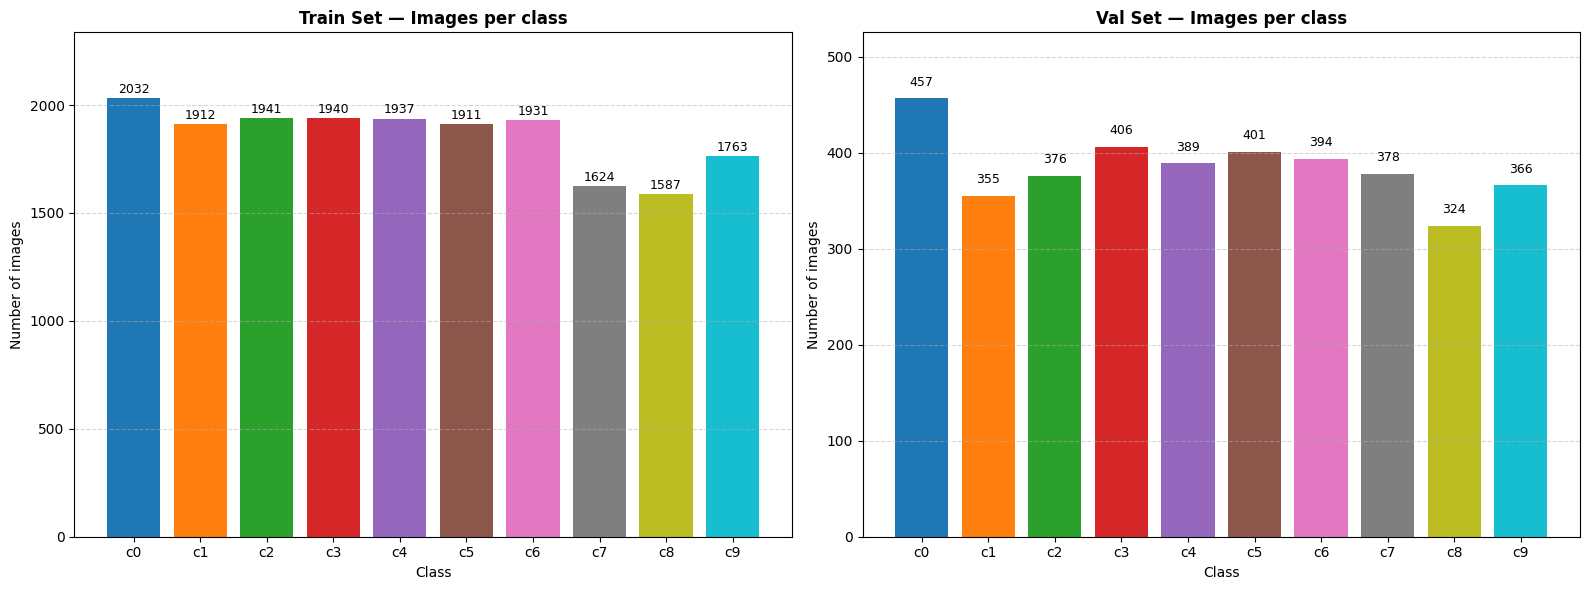


dataset balance training set:
Mean images per class : 1858
dataset is well balanced 


In [ ]:
#class distribution bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = plt.cm.tab10(np.linspace(0, 1, len(df)))

for ax, split, col in zip(axes, ["Train", "Val"], ["steelblue", "darkorange"]):
    bars = ax.bar(df["Class"], df[split], color=colors)
    ax.set_title(f"{split} Set — Images per class", fontweight="bold")
    ax.set_xlabel("Class")
    ax.set_ylabel("Number of images")
    ax.set_ylim(0, df[split].max() * 1.15)
    for bar, val in zip(bars, df[split]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                str(val), ha='center', va='bottom', fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(REPORTS_DIR / "dataset_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

#check balance
train_std  = df["Train"].std()
train_mean = df["Train"].mean()
cv = train_std / train_mean * 100
print(f"\ndataset balance training set:")
print(f"Mean images per class : {train_mean:.0f}")
if cv < 10:
    print("dataset is well balanced ")
elif cv < 20:
    print("dataset is moderately balanced ")
else:
    print("dataset is imbalanced")

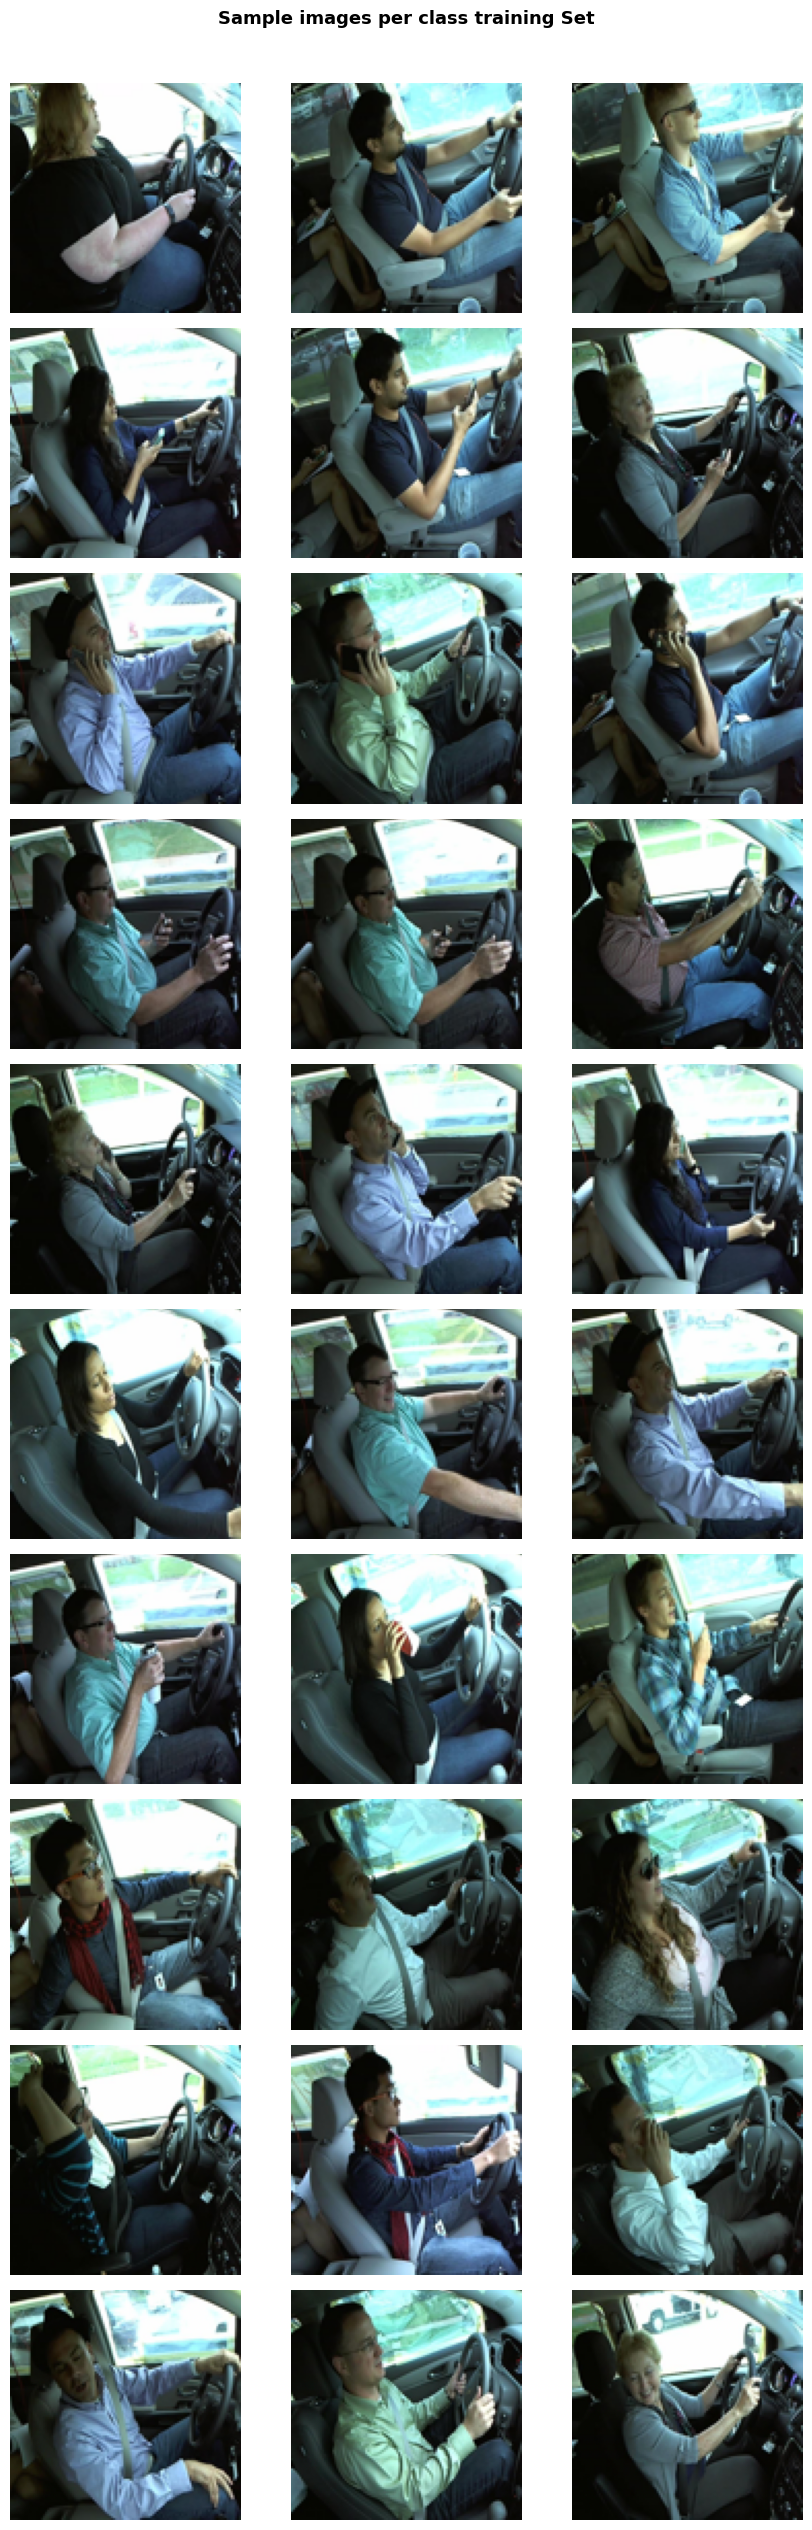

In [6]:
def show_sample_images(split_dir, n_samples=3, save_path=None):
    class_folders = sorted([d for d in split_dir.iterdir() if d.is_dir()])
    n_classes = len(class_folders)

    fig, axes = plt.subplots(n_classes, n_samples, figsize=(n_samples * 3, n_classes * 2.5))

    for row, folder in enumerate(class_folders):
        imgs = [f for f in folder.iterdir()
                if f.suffix.lower() in [".jpg", ".jpeg", ".png"]][:n_samples]
        for col in range(n_samples):
            ax = axes[row][col]
            if col < len(imgs):
                img = Image.open(imgs[col]).resize((112, 112))
                ax.imshow(img)
            ax.axis("off")
            if col == 0:
                label = f"{folder.name}\n{CLASS_NAMES.get(folder.name, '')}"
                ax.set_ylabel(label, fontsize=8, rotation=0,
                              labelpad=60, va='center')

    plt.suptitle("Sample images per class training Set",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()

show_sample_images(TRAIN_DIR, n_samples=3,
    save_path=REPORTS_DIR / "dataset_samples.png")

In [7]:
from ultralytics import YOLO

model_baseline = YOLO("yolov8n-cls.pt")

results_baseline = model_baseline.train(
    data=str(DATA_DIR),
    epochs=50,
    imgsz=224,
    batch=32,
    name="yolov8n_statefarm_subject",
    project="runs",
    # No regularization 
    dropout=0.0,
    weight_decay=0.0005,
    patience=15,    # early stopping 
    plots=True,
    seed=42,
)

New https://pypi.org/project/ultralytics/8.4.37 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.14 🚀 Python-3.12.9 torch-2.10.0 CPU (Apple M5)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/statefarm_subject_split, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_statefarm_subject3, 

In [8]:
model_regularized = YOLO("yolov8n-cls.pt")

results_regularized = model_regularized.train(
    data=str(DATA_DIR),
    epochs=35,
    imgsz=224,
    batch=32,
    name="yolov8n_statefarm_regularized",
    project="runs",

    #Regularization techniques
    dropout=0.1, # randomly drops neurons to reduces overfitting
    weight_decay=0.001,    # L2 regularization to penalises large weights
    patience=10,            # early stopping

    # Data augmentation 
    fliplr=0.5,  # horizontal flip
    degrees=15.0,  # random rotation up to 15 degrees
    scale=0.3,  # random zoom
    hsv_h=0.02,   # hue
    hsv_s=0.7,   # saturation
    hsv_v=0.4,   # brightness
    erasing=0.4,  # random erasing 

    plots=True,
    seed=42,
)

New https://pypi.org/project/ultralytics/8.4.37 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.14 🚀 Python-3.12.9 torch-2.10.0 CPU (Apple M5)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/statefarm_subject_split, degrees=15.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=35, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_statefarm_regularize

In [16]:
import csv
# load training logs saved after each run
def load_training_csv(run_name):

    csv_path = Path(f"runs/{run_name}/results.csv")
    if not csv_path.exists():
        print(f"  results.csv not found at {csv_path}")
        return None
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip() 
    return df


df_base = load_training_csv("yolov8n_statefarm")
df_reg  = load_training_csv("yolov8n_statefarm_regularized")

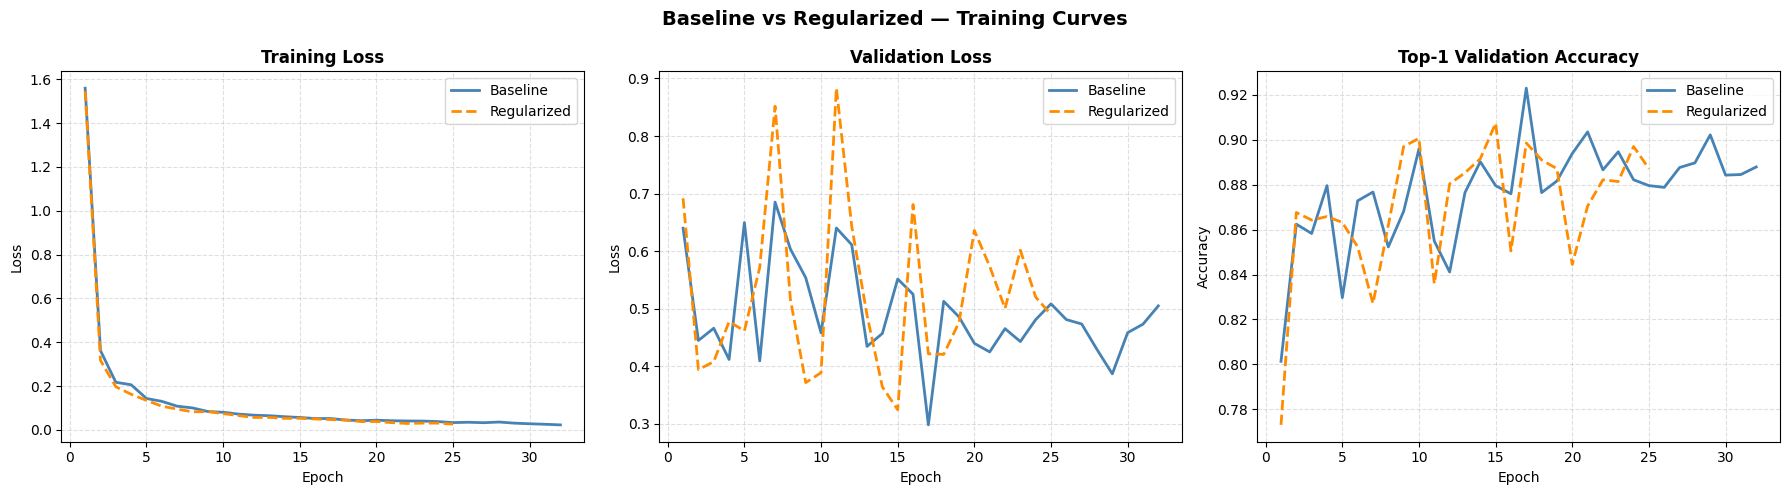

In [ ]:
def plot_training_curves(df_base, df_reg, save_path=None):
    if df_base is None or df_reg is None:
        print("cannot plot results.csv files missing.")
        return

    #identify column names
    def find_col(df, candidates):
        for c in candidates:
            matches = [col for col in df.columns if c.lower() in col.lower()]
            if matches:
                return matches[0]
        return None

    train_loss_col = find_col(df_base, ["train/loss", "train_loss", "loss"])
    val_loss_col   = find_col(df_base, ["val/loss", "val_loss"])
    top1_col       = find_col(df_base, ["metrics/accuracy_top1", "top1", "acc"])

    epochs_b = range(1, len(df_base) + 1)
    epochs_r = range(1, len(df_reg)  + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # training Loss
    if train_loss_col:
        axes[0].plot(epochs_b, df_base[train_loss_col], label="Baseline",    color="steelblue", lw=2)
        axes[0].plot(epochs_r, df_reg[train_loss_col],  label="Regularized", color="darkorange", lw=2, linestyle="--")
        axes[0].set_title("Training Loss", fontweight="bold")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].legend()
        axes[0].grid(True, linestyle="--", alpha=0.4)

    # validation Loss
    if val_loss_col:
        axes[1].plot(epochs_b, df_base[val_loss_col], label="Baseline",    color="steelblue", lw=2)
        axes[1].plot(epochs_r, df_reg[val_loss_col],  label="Regularized", color="darkorange", lw=2, linestyle="--")
        axes[1].set_title("Validation Loss", fontweight="bold")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Loss")
        axes[1].legend()
        axes[1].grid(True, linestyle="--", alpha=0.4)

    # Top 1 Accuracy
    if top1_col:
        axes[2].plot(epochs_b, df_base[top1_col], label="Baseline",    color="steelblue", lw=2)
        axes[2].plot(epochs_r, df_reg[top1_col],  label="Regularized", color="darkorange", lw=2, linestyle="--")
        axes[2].set_title("Top-1 Validation Accuracy", fontweight="bold")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("Accuracy")
        axes[2].legend()
        axes[2].grid(True, linestyle="--", alpha=0.4)

    plt.suptitle("Baseline vs Regularized — Training Curves", fontsize=14, fontweight="bold")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


plot_training_curves(df_base, df_reg,
    save_path=REPORTS_DIR / "training_curves_comparison.png")

In [18]:
def extract_final_metrics(df, model_name):
    if df is None:
        return {}
    top1_col = next((c for c in df.columns if "top1" in c.lower() or "accuracy" in c.lower()), None)
    loss_col  = next((c for c in df.columns if "val" in c.lower() and "loss" in c.lower()), None)

    best_acc  = df[top1_col].max()  if top1_col else "N/A"
    best_epoch = int(df[top1_col].idxmax()) + 1 if top1_col else "N/A"
    final_val_loss = df[loss_col].iloc[-1] if loss_col else "N/A"

    print(f"\n{model_name} Model:")
    print(f"  Best Top-1 Accuracy : {best_acc:.4f} ({best_acc*100:.2f}%) at epoch {best_epoch}")
    print(f"  Final Val Loss      : {final_val_loss:.5f}" if loss_col else "  Final Val Loss: N/A")
    print(f"  Total Epochs        : {len(df)}")

extract_final_metrics(df_base, "Baseline")
extract_final_metrics(df_reg,  "Regularized")

comparison = pd.DataFrame([
    {"Setting": "Model",          "Baseline": "YOLOv8n-cls",   "Regularized": "YOLOv8n-cls"},
    {"Setting": "Epochs",         "Baseline": "50",             "Regularized": "35 (+ early stop)"},
    {"Setting": "Batch Size",     "Baseline": "32",             "Regularized": "32"},
    {"Setting": "Image Size",     "Baseline": "224x224",        "Regularized": "224x224"},
    {"Setting": "Dropout",        "Baseline": "0.0",            "Regularized": "0.3"},
    {"Setting": "Weight Decay",   "Baseline": "0.0005",         "Regularized": "0.001"},
    {"Setting": "Early Stopping", "Baseline": "Off (p=100)",    "Regularized": "On (p=5)"},
    {"Setting": "Augmentation",   "Baseline": "Default only",   "Regularized": "+ rotate/scale/erase"},
    {"Setting": "Flip LR",        "Baseline": "0.5",            "Regularized": "0.5"},
])
print(comparison.to_string(index=False))


Baseline Model:
  Best Top-1 Accuracy : 0.9230 (92.30%) at epoch 17
  Final Val Loss      : 0.50496
  Total Epochs        : 32

Regularized Model:
  Best Top-1 Accuracy : 0.9074 (90.74%) at epoch 15
  Final Val Loss      : 0.48981
  Total Epochs        : 25
       Setting     Baseline          Regularized
         Model  YOLOv8n-cls          YOLOv8n-cls
        Epochs           50    35 (+ early stop)
    Batch Size           32                   32
    Image Size      224x224              224x224
       Dropout          0.0                  0.3
  Weight Decay       0.0005                0.001
Early Stopping  Off (p=100)             On (p=5)
  Augmentation Default only + rotate/scale/erase
       Flip LR          0.5                  0.5
